# Lumpyspace: Live Training Monitor
This notebook provides real-time visualization of the PINN training progress by reading the live CSV logs generated by `src/training/run.py`.

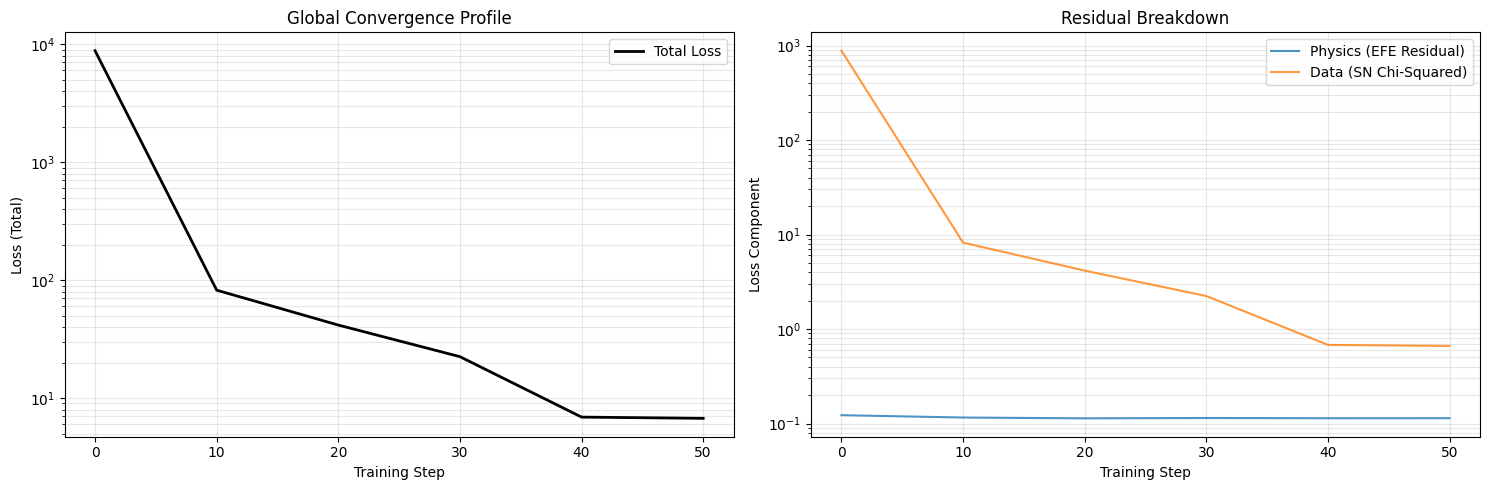

Last Update: 21:45:34 | Steps: 50 | Current Loss: 6.736e+00 | Physics Loss: 1.138e-01 | Data Loss: 6.623e-01


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import os

# Path to the production logs
log_path = "../logs/training_metrics.csv"

def monitor_convergence():
    while True:
        if not os.path.exists(log_path):
            clear_output(wait=True)
            print(f"Waiting for log file: {log_path}...")
            time.sleep(5)
            continue
            
        try:
            df = pd.read_csv(log_path)
            if len(df) > 1:
                clear_output(wait=True)
                fig, ax = plt.subplots(1, 2, figsize=(15, 5))
                
                # Plot Total Loss (Log Scale)
                ax[0].plot(df['step'], df['loss'].astype(float), label='Total Loss', color='black', linewidth=2)
                ax[0].set_yscale('log')
                ax[0].set_xlabel('Training Step')
                ax[0].set_ylabel('Loss (Total)')
                ax[0].set_title('Global Convergence Profile')
                ax[0].grid(True, which="both", ls="-", alpha=0.3)
                ax[0].legend()
                
                # Plot Components
                ax[1].plot(df['step'], df['l_phys'].astype(float), label='Physics (EFE Residual)', alpha=0.8)
                ax[1].plot(df['step'], df['l_data'].astype(float), label='Data (SN Chi-Squared)', alpha=0.8)
                ax[1].set_yscale('log')
                ax[1].set_xlabel('Training Step')
                ax[1].set_ylabel('Loss Component')
                ax[1].set_title('Residual Breakdown')
                ax[1].grid(True, which="both", ls="-", alpha=0.3)
                ax[1].legend()
                
                plt.tight_layout()
                plt.show()
                
                print(f"Last Update: {time.strftime('%H:%M:%S')} | "
                      f"Steps: {df['step'].iloc[-1]} | "
                      f"Current Loss: {df['loss'].iloc[-1]:.3e} | "
                      f"Physics Loss: {df['l_phys'].iloc[-1]:.3e} | "
                      f"Data Loss: {df['l_data'].iloc[-1]:.3e}")
        except Exception as e:
            print(f"Error reading logs: {e}")
        
        time.sleep(10) # Refresh every 10 seconds to reduce IO overhead

monitor_convergence()

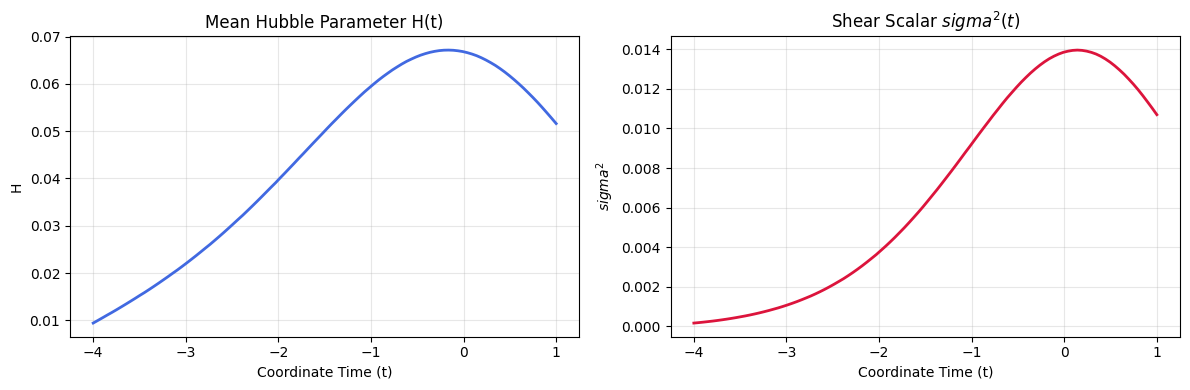

In [ ]:
import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
import matplotlib.pyplot as plt
import equinox as eqx
import sys
import os

# Ensure notebook can find the src module
sys.path.append(os.path.abspath('..'))
#sys.path.insert(0, '/home/dma/dev/lumpyspace')

from src.core.metric import MetricNN

# 1. Load the checkpoint
checkpoint_path = "../checkpoints/pinn_metric.eqx"
key = jax.random.PRNGKey(0)
model_skeleton = MetricNN(key) # Blank structure
# Hydrate the model with your trained weights
model = eqx.tree_deserialise_leaves(checkpoint_path, model_skeleton)

# 2. The Extraction Math
def extract_cosmology(model, t_eval):
    def compute_kinematics(t):
        coords = jnp.array([t, 0.0, 0.0, 0.0])
        g = model(coords)
        
        # Spatial Metric
        g_spatial = g[1:4, 1:4]
        g_spatial_inv = jnp.linalg.inv(g_spatial)
        
        # d/dt g_ij (Derivative wrt coordinate time)
        dg_dt = jacfwd(model)(coords)[:, :, 0]
        dg_spatial_dt = dg_dt[1:4, 1:4]
        
        # Lapse function alpha
        alpha = jnp.sqrt(-g[0, 0])
        
        # Expansion & Hubble Tensors
        theta_ij = (1.0 / (2.0 * alpha)) * dg_spatial_dt
        H_tensor = jnp.einsum('ik,kj->ij', g_spatial_inv, theta_ij)
        
        H_mean = jnp.trace(H_tensor) / 3.0
        
        # Extract the directional expansion rates
        H_x, H_y, H_z = H_tensor[0,0], H_tensor[1,1], H_tensor[2,2]
        
        # Shear Tensor and Scalar
        sigma_tensor = H_tensor - H_mean * jnp.eye(3)
        sigma_sq = 0.5 * jnp.einsum('ij,ji->', sigma_tensor, sigma_tensor)
        
        return H_mean, sigma_sq, H_x, H_y, H_z
        
    return vmap(compute_kinematics)(t_eval)

# 3. Evaluate and Plot
t_eval = jnp.linspace(-4.0, 1.0, 100)

# Unpack all 5 variables
H_mean, sigma_sq, H_x, H_y, H_z = extract_cosmology(model, t_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- LEFT CHART: Directional Expansion Rates ---
# Plot the mean as a solid thick black line
ax1.plot(t_eval, H_mean, color='black', linewidth=3, label='H_mean')

# Plot the directional components as dashed colored lines
ax1.plot(t_eval, H_x, color='red', linestyle='--', linewidth=2, label='H_x')
ax1.plot(t_eval, H_y, color='green', linestyle='--', linewidth=2, label='H_y')
ax1.plot(t_eval, H_z, color='blue', linestyle='--', linewidth=2, label='H_z')

ax1.set_xlabel('Coordinate Time (t)')
ax1.set_ylabel('Hubble Parameter (H)')
ax1.set_title('Directional Expansion Rates H(t)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- RIGHT CHART: Shear Scalar ---
ax2.plot(t_eval, sigma_sq, color='crimson', linewidth=2)
ax2.set_xlabel('Coordinate Time (t)')
ax2.set_ylabel(r'Shear Scalar $\sigma^2$')
ax2.set_title(r'Shear Scalar $\sigma^2(t)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

